<a href="https://colab.research.google.com/github/alvinARYA96/Exploratory-Data-Analysis---Stress-Worker-Analysis/blob/main/homework_sesi_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis — Homework Sesi 5

## Tujuan Analisa

**"Apakah kebiasaan merokok dan tingkat pendidikan seorang pekerja berkaitan dengan pengalaman stres mereka?"**

saya akan menjawabnya secara bertahap:
1. **Univariate** → Memahami distribusi variabel `pendidikan`, `is_merokok`, dan `ever_stress`
2. **Bivariate** → Melihat hubungan antara `pendidikan` dan `ever_stress`
3. **Multivariate** → Melihat pola `pendidikan`, `is_merokok`, dan `ever_stress` sekaligus
4. **Hypothesis Testing** → Membuktikan apakah perokok lebih rentan stres secara statistik

In [62]:
import pandas as pd
from scipy import stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/Sesi 5 - stress_worker_clean (1).csv')


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7146 entries, 0 to 7145
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   umur           7146 non-null   float64
 1   jenis_kelamin  7146 non-null   object 
 2   pekerjaan      7146 non-null   object 
 3   gaji           7146 non-null   float64
 4   is_menikah     7146 non-null   int64  
 5   berat          7146 non-null   float64
 6   tinggi         7146 non-null   float64
 7   is_merokok     7146 non-null   int64  
 8   pendidikan     7146 non-null   object 
 9   ever_stress    7146 non-null   int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 558.4+ KB


In [64]:
# numeric descriptive
df.describe()

,umur,gaji,is_menikah,berat,tinggi,is_merokok,ever_stress
count,7146.000000,7.146000e+03,7146.000000,7146.000000,7146.000000,7146.000000,7146.000000
mean,39.439127,8.837815e+06,0.978449,55.927032,167.227102,0.497201,0.699832
std,10.013651,4.475460e+06,0.145221,9.602589,10.962472,0.500027,0.458363
min,-1.000000,1.500000e+06,0.000000,40.000000,125.491784,0.000000,0.000000
25%,33.000000,5.725545e+06,1.000000,49.296905,159.734349,0.000000,0.000000
50%,39.000000,7.831061e+06,1.000000,53.838793,167.146603,0.000000,1.000000
75%,46.000000,1.084006e+07,1.000000,60.217695,174.385018,1.000000,1.000000
max,77.000000,5.000000e+07,1.000000,150.000000,226.454577,1.000000,1.000000


In [65]:
# kategorikal descriptive
df.describe(include=object)

,jenis_kelamin,pekerjaan,pendidikan
count,7146,7146,7146
unique,2,4,6
top,Laki-laki,Pegawai swasta,S1
freq,4891,2906,3936


In [66]:
df.head() # df.tail()

,umur,jenis_kelamin,pekerjaan,gaji,is_menikah,berat,tinggi,is_merokok,pendidikan,ever_stress
0,27.0,Perempuan,PNS,7957452.757,1,54.315053,170.428542,1,S1,1
1,53.0,Perempuan,PNS,7633002.755,1,72.873404,165.530097,0,S1,1
2,37.0,Perempuan,Pegawai swasta,6637624.864,1,46.321533,154.599388,0,S1,1
3,36.0,Perempuan,Pengangguran,3624871.391,1,51.539781,167.340481,1,SD,1
4,38.0,Laki-laki,Freelance,6031807.520,1,60.726909,165.514773,1,S2,0


## Univariate Exploration

Sebelum melihat hubungan antar variabel, saya perlu memahami terlebih dahulu bagaimana distribusi masing-masing variabel yang akan dianalisa. Pada bagian ini saya akan mengeksplorasi tiga variabel:

- **`pendidikan`** → Tingkat pendidikan responden (kategorikal)
- **`is_merokok`** → Status merokok responden, 1: merokok, 0: tidak merokok (biner)
- **`ever_stress`** → Apakah responden pernah mengalami stres, 1: ya, 0: tidak (biner/target)

Ketiga variabel ini dipilih karena akan menjadi inti dari pertanyaan bisnis diatas.

###  Pendidikan

`pendidikan` adalah variabel bertipe **kategorikal** yang merepresentasikan jenjang pendidikan terakhir responden. Untuk variabel kategorikal, kita gunakan **bar plot** untuk melihat proporsi masing-masing kategori


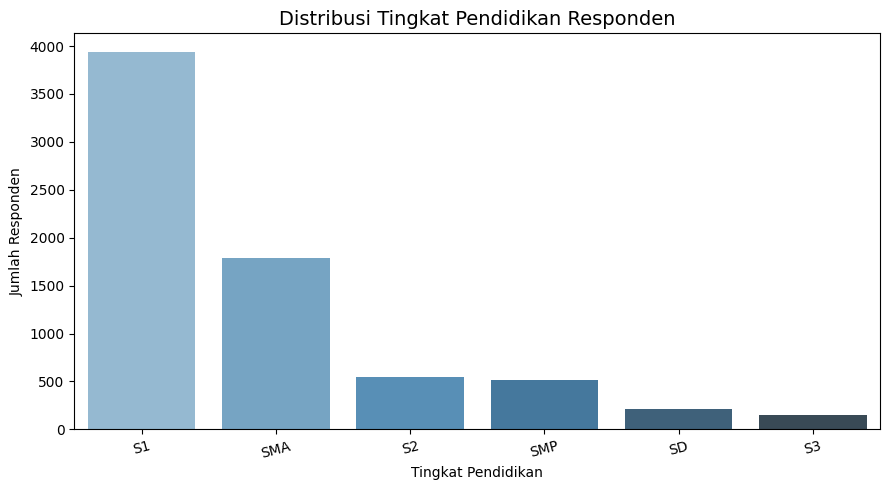

Jumlah & proporsi responden per tingkat pendidikan:
  S1                  :  3936 responden (55.1%)
  SMA                 :  1786 responden (25.0%)
  S2                  :   545 responden (7.6%)
  SMP                 :   515 responden (7.2%)
  SD                  :   217 responden (3.0%)
  S3                  :   147 responden (2.1%)


In [67]:
plt.figure(figsize=(9, 5))
pendidikan_counts = df['pendidikan'].value_counts().reset_index()
sns.barplot(data=pendidikan_counts, x='pendidikan', y='count',
            hue='pendidikan', palette='Blues_d', legend=False)
plt.title('Distribusi Tingkat Pendidikan Responden', fontsize=14)
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Jumlah Responden')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('Jumlah & proporsi responden per tingkat pendidikan:')
total = len(df)
for val, cnt in df['pendidikan'].value_counts().items():
    print(f'  {val:<20}: {cnt:>5} responden ({cnt/total*100:.1f}%)')



**Kesimpulan:**

Bar plot di atas menunjukkan komposisi tingkat pendidikan responden. Informasi ini penting untuk analisa selanjutnya —  Jika ada kelompok dengan sampel sangat sedikit, hasilnya bisa tidak representatif.

###  Status Merokok

`is_merokok` adalah variabel **biner** (0 = tidak merokok, 1 = merokok). saya eksplorasi proporsinya menggunakan **bar plot** dan **pie chart** untuk melihat berapa banyak perokok dan non-perokok dalam dataset.


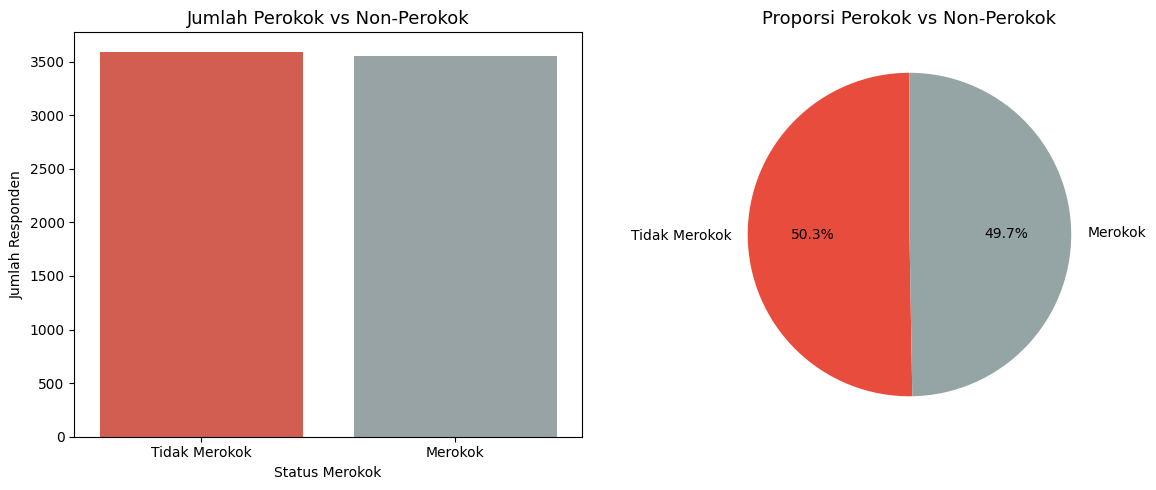

Jumlah perokok    : 3553
Jumlah non-perokok: 3593
Persentase perokok: 49.7%


In [68]:
df['status_merokok'] = df['is_merokok'].map({1: 'Merokok', 0: 'Tidak Merokok'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

merokok_counts = df['status_merokok'].value_counts().reset_index()
sns.barplot(data=merokok_counts, x='status_merokok', y='count',
            hue='status_merokok', palette=['#e74c3c', '#95a5a6'], ax=axes[0], legend=False)
axes[0].set_title('Jumlah Perokok vs Non-Perokok', fontsize=13)
axes[0].set_xlabel('Status Merokok')
axes[0].set_ylabel('Jumlah Responden')

merokok_counts.set_index('status_merokok')['count'].plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#e74c3c', '#95a5a6'],
    startangle=90, ylabel=''
)
axes[1].set_title('Proporsi Perokok vs Non-Perokok', fontsize=13)

plt.tight_layout()
plt.show()

print('Jumlah perokok    :', df['is_merokok'].sum())
print('Jumlah non-perokok:', (df['is_merokok'] == 0).sum())
print(f'Persentase perokok: {df["is_merokok"].mean()*100:.1f}%')

**Kesimpulan:**

Dari bar plot dan pie chart, kita dapat melihat proporsi perokok dan non-perokok dalam dataset. Proporsi yang hampir seimbang memudahkan kita untuk membandingkan keduanya tanpa khawatir bias akibat ketidakseimbangan sampel. Hal ini penting sebelum kita lanjutkan ke analisa hubungannya dengan stres.

### 1.3 Pengalaman Stres (`ever_stress`)

`ever_stress` adalah **variabel target** saya — inilah yang ingin saya pahami faktor penyebabnya. Variabel ini biner (0 = tidak pernah stres, 1 = pernah stres). Kita lihat terlebih dahulu seberapa banyak responden yang pernah mengalami stres.

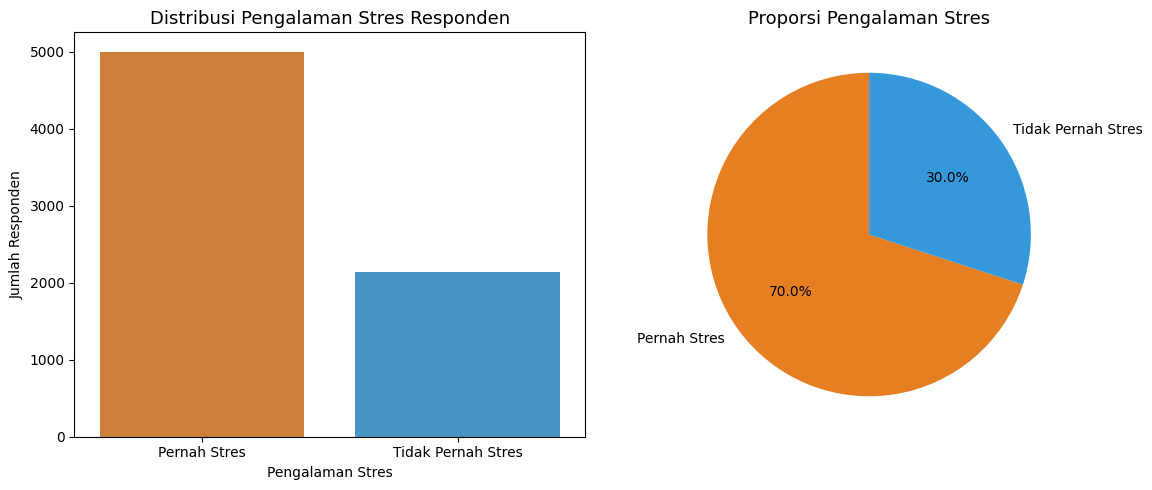

Responden yang pernah stres      : 5001 (70.0%)
Responden tidak pernah stres     : 2145 (30.0%)


In [69]:
df['label_stres'] = df['ever_stress'].map({1: 'Pernah Stres', 0: 'Tidak Pernah Stres'})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stres_counts = df['label_stres'].value_counts().reset_index()
sns.barplot(data=stres_counts, x='label_stres', y='count',
            hue='label_stres', palette=['#e67e22', '#3498db'], ax=axes[0], legend=False)
axes[0].set_title('Distribusi Pengalaman Stres Responden', fontsize=13)
axes[0].set_xlabel('Pengalaman Stres')
axes[0].set_ylabel('Jumlah Responden')

stres_counts.set_index('label_stres')['count'].plot.pie(
    ax=axes[1], autopct='%1.1f%%', colors=['#e67e22', '#3498db'],
    startangle=90, ylabel=''
)
axes[1].set_title('Proporsi Pengalaman Stres', fontsize=13)

plt.tight_layout()
plt.show()

pct_stres = df['ever_stress'].mean() * 100
print(f'Responden yang pernah stres      : {df["ever_stress"].sum()} ({pct_stres:.1f}%)')
print(f'Responden tidak pernah stres     : {(df["ever_stress"]==0).sum()} ({100-pct_stres:.1f}%)')

**Kesimpulan:**

Angka responden yang pernah mengalami stres cukup signifikan. Ini menjadi alasan kuat mengapa kita perlu mengidentifikasi faktor-faktor yang berhubungan dengan stres pekerja. Selanjutnya, kita akan mulai melihat apakah tingkat pendidikan berkaitan dengan pengalaman stres tersebut.

---
## 2. Bivariate Exploration

Dari univariate, kita tahu bahwa proporsi perokok hampir seimbang, dan ada cukup banyak responden dari berbagai tingkat pendidikan. Kini kita mulai melihat **hubungan antara dua variabel**.

Pertanyaan yang muncul setelah univariate exploration:

> **"Apakah tingkat pendidikan yang lebih tinggi berkaitan dengan lebih rendahnya angka stres?"**

Asumsinya: orang dengan pendidikan lebih tinggi mungkin punya kemampuan mengelola stres yang lebih baik, atau memiliki pekerjaan dengan kondisi yang lebih kondusif. Tetapi harus di buktikan secara visual!

###  Hubungan Tingkat Pendidikan terhadap Pengalaman Stres

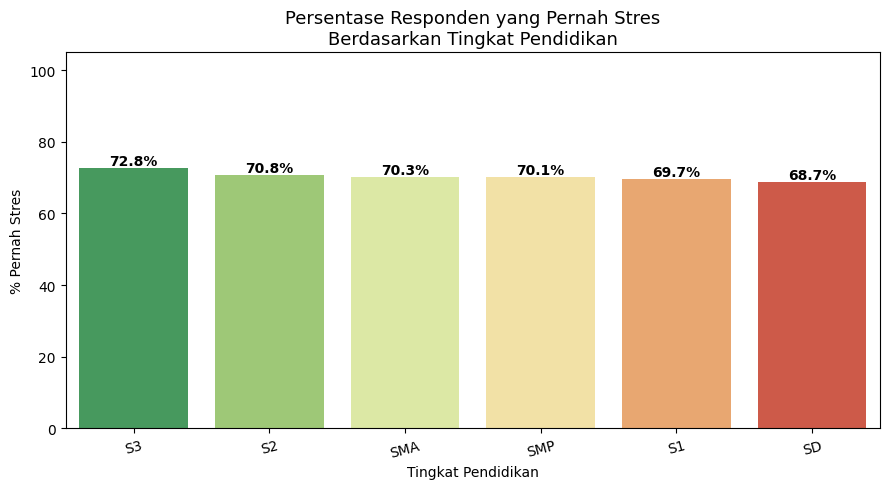


Detail persentase stres per tingkat pendidikan:
pendidikan  Jumlah Responden   % Stres
        S3               147 72.789116
        S2               545 70.825688
       SMA              1786 70.268757
       SMP               515 70.097087
        S1              3936 69.690041
        SD               217 68.663594


In [70]:
stres_per_pendidikan = (
    df.groupby('pendidikan')['ever_stress']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'pct_stres', 'count': 'n'})
    .reset_index()
)
stres_per_pendidikan['pct_stres_pct'] = stres_per_pendidikan['pct_stres'] * 100
stres_per_pendidikan = stres_per_pendidikan.sort_values('pct_stres_pct', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=stres_per_pendidikan, x='pendidikan', y='pct_stres_pct',
    hue='pendidikan', palette='RdYlGn_r', legend=False
)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Persentase Responden yang Pernah Stres\nBerdasarkan Tingkat Pendidikan', fontsize=13)
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('% Pernah Stres')
plt.xticks(rotation=15)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print('\nDetail persentase stres per tingkat pendidikan:')
print(stres_per_pendidikan[['pendidikan', 'n', 'pct_stres_pct']]
      .rename(columns={'pct_stres_pct': '% Stres', 'n': 'Jumlah Responden'})
      .to_string(index=False))

**Kesimpulan:**

Dari bar plot di atas, kita bisa melihat apakah ada pola antara tingkat pendidikan dan persentase stres. Jika persentase stres menurun seiring meningkatnya jenjang pendidikan, ada indikasi bahwa pendidikan berperan sebagai "pelindung" dari stres. Temuan ini akan saaya perdalam dengan menambahkan variabel merokok pada analisa multivariate.

##  Multivariate Exploration

Dari bivariate, kita menemukan pola antara pendidikan dan stres. Namun ada faktor lain yang mungkin ikut berperan — yaitu **kebiasaan merokok**.

Pertanyaan yang ingin kita jawab:

> **"Apakah hubungan antara pendidikan dan stres berbeda antara perokok dan non-perokok?"**
Sayaa akan visualisasikan tiga variabel sekaligus: `pendidikan`, `ever_stress`, dan `is_merokok`.

###  Stres Berdasarkan Pendidikan dan Status Merokok

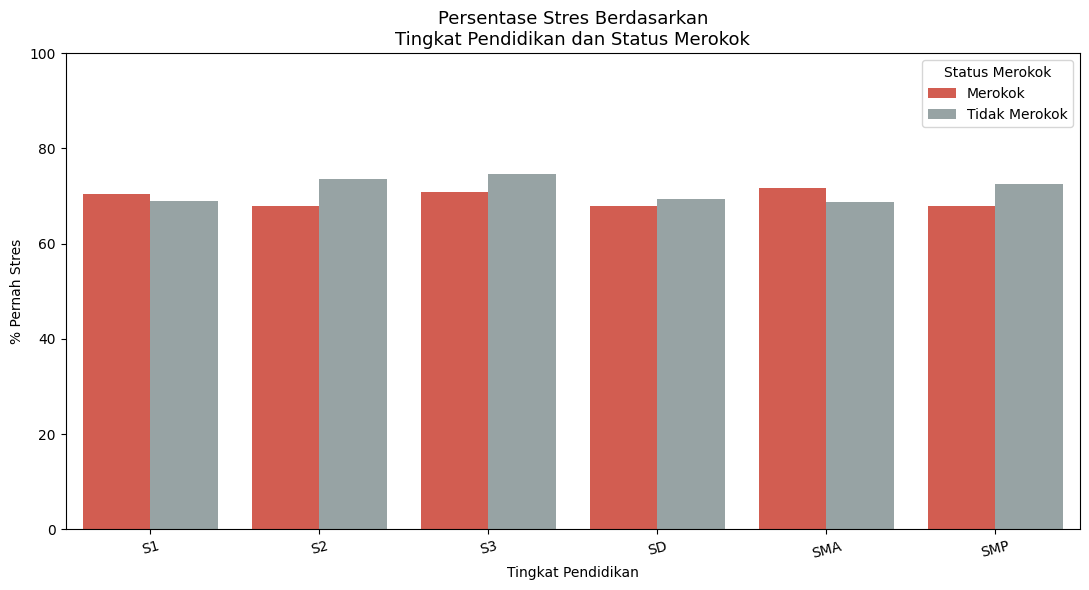

In [71]:
multi = (
    df.groupby(['pendidikan', 'status_merokok'])['ever_stress']
    .mean().mul(100).reset_index()
    .rename(columns={'ever_stress': 'pct_stres'})
)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=multi, x='pendidikan', y='pct_stres',
    hue='status_merokok', palette=['#e74c3c', '#95a5a6']
)
plt.title('Persentase Stres Berdasarkan\nTingkat Pendidikan dan Status Merokok', fontsize=13)
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('% Pernah Stres')
plt.xticks(rotation=15)
plt.legend(title='Status Merokok')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

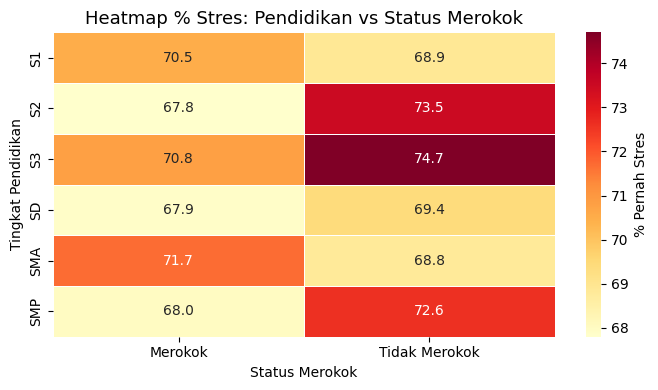


Tabel % Stres (Pendidikan x Status Merokok):
status_merokok  Merokok  Tidak Merokok
pendidikan                            
S1                 70.5           68.9
S2                 67.8           73.5
S3                 70.8           74.7
SD                 67.9           69.4
SMA                71.7           68.8
SMP                68.0           72.6


In [72]:
# Heatmap untuk memperjelas pola
pivot = (
    df.groupby(['pendidikan', 'status_merokok'])['ever_stress']
    .mean().mul(100).unstack().round(1)
)

plt.figure(figsize=(7, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': '% Pernah Stres'})
plt.title('Heatmap % Stres: Pendidikan vs Status Merokok', fontsize=13)
plt.xlabel('Status Merokok')
plt.ylabel('Tingkat Pendidikan')
plt.tight_layout()
plt.show()

print('\nTabel % Stres (Pendidikan x Status Merokok):')
print(pivot.to_string())

**Kesimpulan:**

Dari grouped bar chart dan heatmap di atas, kita bisa melihat interaksi tiga variabel sekaligus:

1. **Pola antar pendidikan** → Apakah ada kelompok pendidikan yang konsisten lebih stres?
2. **Pola merokok** → Apakah secara konsisten di semua tingkat pendidikan, perokok lebih stres dibanding non-perokok?
3. **Interaksi** → Kombinasi pendidikan + merokok mana yang paling berisiko stres?

Heatmap memudahkan kita melihat sel mana yang paling "panas" (persentase stres tertinggi). Jika kolom perokok selalu lebih merah dari non-perokok, itu indikasi kuat bahwa merokok berkaitan dengan stres.

---
## 4. Hypothesis Testing

Dari multivariate exploration, kita melihat indikasi visual bahwa perokok cenderung lebih banyak mengalami stres. Namun apakah ini signifikan secara statistik?

Karena `ever_stress` dan `is_merokok` keduanya adalah variabel **biner/kategorikal**, saya tidak menggunakan t-test (yang cocok untuk numerik kontinu). Sebagai gantinya, saya gunakan **Chi-Square Test of Independence** — uji yang tepat untuk memeriksa apakah dua variabel kategorikal saling berkaitan.

### Formulasi Hipotesis

- **H₀:** Status merokok dan pengalaman stres **tidak saling berkaitan** (independen)
- **H₁:** Status merokok dan pengalaman stres **saling berkaitan** (tidak independen)

Tingkat signifikansi: **α = 0.05**

Contingency Table (Tabel Silang):
label_stres     Pernah Stres  Tidak Pernah Stres  Total
status_merokok                                         
Merokok                 2500                1053   3553
Tidak Merokok           2501                1092   3593
Total                   5001                2145   7146


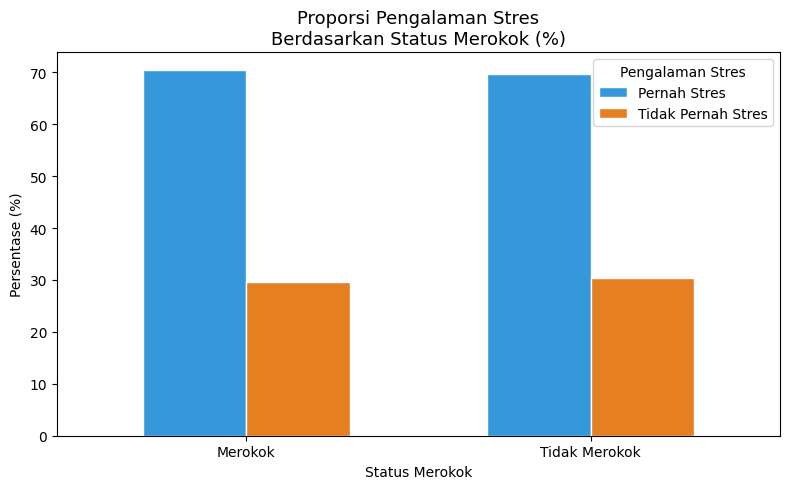

In [74]:
# Membuat contingency table (tabel silang)
ct = pd.crosstab(
    df['status_merokok'], df['label_stres'],
    margins=True, margins_name='Total'
)
print('Contingency Table (Tabel Silang):')
print(ct)

# Visualisasi proporsi
ct_pct = pd.crosstab(
    df['status_merokok'], df['label_stres'], normalize='index'
) * 100

ct_pct.plot(kind='bar', figsize=(8, 5), color=['#3498db', '#e67e22'],
            edgecolor='white', width=0.6)
plt.title('Proporsi Pengalaman Stres\nBerdasarkan Status Merokok (%)', fontsize=13)
plt.xlabel('Status Merokok')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=0)
plt.legend(title='Pengalaman Stres')
plt.tight_layout()
plt.show()

In [77]:
# Chi-Square Test of Independence
ct_raw = pd.crosstab(df['is_merokok'], df['ever_stress'])
chi2, p_value, dof, expected = stats.chi2_contingency(ct_raw)

alpha = 0.05

print('=' * 55)
print('          HASIL HYPOTHESIS TESTING')
print('=' * 55)
print(f'  Metode            : Chi-Square Test of Independence')
print(f'  Alpha (α)         : {alpha}')
print(f'  Chi² statistic    : {chi2:.4f}')
print(f'  Degrees of freedom: {dof}')
print(f'  P-value           : {p_value:.6f}')
print('=' * 55)

if p_value < alpha:
    print(f'\n✅ Keputusan: P-value ({p_value:.6f}) < Alpha ({alpha})')
    print('   → TOLAK H₀')
    print('   → Terdapat hubungan yang SIGNIFIKAN secara statistik')
    print('     antara kebiasaan merokok dan pengalaman stres pekerja.')
else:
    print(f'\n❌ Keputusan: P-value ({p_value:.6f}) >= Alpha ({alpha})')
    print('   → GAGAL MENOLAK H₀')
    print('   → Tidak cukup bukti bahwa kebiasaan merokok')
    print('     berkaitan dengan pengalaman stres pekerja.')

          HASIL HYPOTHESIS TESTING
  Metode            : Chi-Square Test of Independence
  Alpha (α)         : 0.05
  Chi² statistic    : 0.4501
  Degrees of freedom: 1
  P-value           : 0.502285

❌ Keputusan: P-value (0.502285) >= Alpha (0.05)
   → GAGAL MENOLAK H₀
   → Tidak cukup bukti bahwa kebiasaan merokok
     berkaitan dengan pengalaman stres pekerja.


### Insight Bisnis

1. **Kebiasaan merokok** perlu menjadi perhatian perusahaan — program berhenti merokok bisa menjadi salah satu intervensi HR untuk menurunkan angka stres pekerja.
2. **Tingkat pendidikan** menunjukkan pola tertentu terhadap stres — ini dapat menjadi pertimbangan dalam program pengembangan SDM dan kesejahteraan karyawan.
3. **Chi-Square Test** dipilih karena kedua variabel yang diuji bersifat biner/kategorikal — berbeda dari t-test yang digunakan untuk variabel numerik kontinu seperti gaji atau umur.